# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.12.12 | scikit-learn 1.8.0


In [2]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [3]:
def regression_metrics(y_true, y_pred):
    """Return a dict with keys 'mse', 'rmse', 'mae', 'r2'.

        mse  = mean of the squared errors
        rmse = square root of mse
        mae  = mean of the absolute errors
        r2   = 1 - (sum of squared errors) / (sum of squared deviations
               of y_true from its own mean)

    Return Python/NumPy floats. Do not import from sklearn.metrics.
    """
    errors = y_true - y_pred
    mse = float(np.mean(errors ** 2))
    return {
        "mse": mse,
        "rmse": float(np.sqrt(mse)),
        "mae": float(np.mean(np.abs(errors))),
        "r2": float(1 - np.sum(errors ** 2) / np.sum((y_true - y_true.mean()) ** 2)),
    }

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [5]:
_q1_X = bikes[["temp", "hum", "windspeed"]].values
_q1_y = bikes["cnt"].values.astype(float)
_q1_Xtr, _q1_Xte, _q1_ytr, _q1_yte, _q1_itr, _q1_ite = train_test_split(
    _q1_X, _q1_y, bikes.index.values, test_size=0.25, random_state=SEED
)
_q1_pred = LinearRegression().fit(_q1_Xtr, _q1_ytr).predict(_q1_Xte)
_q1_m = regression_metrics(_q1_yte, _q1_pred)
print("temp, hum, windspeed:", {k: round(float(v), 4) for k, v in _q1_m.items()})
print(f"mean hourly demand in the test set: {_q1_yte.mean():.2f}, sd {_q1_yte.std():.2f}")
print(f"RMSE / MAE = {_q1_m['rmse'] / _q1_m['mae']:.3f}")
print(f"median absolute error {np.median(np.abs(_q1_yte - _q1_pred)):.2f}")

_q1_worst = bikes.loc[_q1_ite, ["dteday", "hr", "workingday", "weathersit", "temp", "cnt"]].copy()
_q1_worst["predicted"] = _q1_pred
_q1_worst["error"] = _q1_yte - _q1_pred
_q1_worst["temp"] = (_q1_worst["temp"] * 41).round(1)
print("\nten worst-predicted hours:")
print(_q1_worst.reindex(_q1_worst["error"].abs().sort_values(ascending=False).index).head(10)
      .to_string(index=False))

_q1_hr = pd.get_dummies(bikes["hr"].astype("category"), prefix="hr", dtype=int).values
_q1_X_hr = np.hstack([_q1_X, _q1_hr])
_q1_Xtr2, _q1_Xte2, _q1_ytr2, _q1_yte2 = train_test_split(_q1_X_hr, _q1_y, test_size=0.25, random_state=SEED)
_q1_m2 = regression_metrics(_q1_yte2, LinearRegression().fit(_q1_Xtr2, _q1_ytr2).predict(_q1_Xte2))
print("\nwith one-hot hr:", {k: round(float(v), 4) for k, v in _q1_m2.items()})

_q1_X_int = np.hstack([_q1_X, bikes[["hr"]].values])
_q1_Xtr3, _q1_Xte3, _q1_ytr3, _q1_yte3 = train_test_split(_q1_X_int, _q1_y, test_size=0.25, random_state=SEED)
_q1_m3 = regression_metrics(_q1_yte3, LinearRegression().fit(_q1_Xtr3, _q1_ytr3).predict(_q1_Xte3))
print("with hr as one integer column:", {k: round(float(v), 4) for k, v in _q1_m3.items()})

temp, hum, windspeed: {'mse': 25094.1254, 'rmse': 158.4113, 'mae': 118.9047, 'r2': 0.2511}
mean hourly demand in the test set: 191.11, sd 183.05
RMSE / MAE = 1.332
median absolute error 92.86

ten worst-predicted hours:
    dteday  hr  workingday  weathersit    temp  cnt  predicted    error
2012-09-27  17           1           2 27.1000  905   232.4244 672.5756
2012-10-03  17           1           1 28.7000  917   254.7702 662.2298
2012-10-24   8           1           2 21.3000  801   141.3304 659.6696
2012-09-26   8           1           1 23.0000  838   185.2947 652.7053
2012-10-03   8           1           2 25.4000  809   163.7160 645.2840
2012-10-23  17           1           1 27.9000  938   313.5283 624.4717
2012-04-20   8           1           1 18.0000  700    81.0947 618.9053
2012-08-20  17           1           1 28.7000  893   276.9653 616.0347
2012-10-23   8           1           2 18.9000  761   149.7390 611.2610
2012-10-12   8           1           1 17.2000  745   138.03

**Your answer:**

Linear regression on `temp`, `hum` and `windspeed` only, test set (25 %): MSE 25 094.1, RMSE 158.41, MAE 118.90, R² 0.2511.

**(a)** RMSE = 158.4 means that the model's predictions are typically off by about 158 bicycles per hour, in the same units as `cnt`. That is a lot, because the average hour in the test set has only 191 rentals (sd 183). MSE (25 094) is the average of the squared errors, so its unit is "bicycles squared". It cannot be read as a number of bicycles, and since it squares the errors, a single hour that is off by 600 counts as much as 36 hours that are off by 100. It is only useful for comparing models with each other, not for saying how wrong one prediction is.

**(b)** RMSE / MAE = 158.41 / 118.90 = 1.33, and the median absolute error is only 92.9. If all errors had the same size the ratio would be exactly 1. A ratio well above 1 means the errors are uneven: most hours are predicted moderately badly, and a smaller number of hours are predicted very badly, and RMSE is pulled up by those because it squares them. The ten worst hours confirm this. Every one of them is on a **working day**, at **8:00 or 17:00** (the commuter peaks), in 2012, mostly in September and October, with 700 to 938 actual rentals, while the model predicted only 81 to 314 (errors of 607 to 673). The model only sees the weather, so it has no way to know that 8:00 on a working day is completely different from 3:00 at night with the same temperature.

**(c)** Adding the 24 one-hot `hr` columns raises R² from 0.2511 to 0.6052 (RMSE from 158.4 to 115.0, MAE from 118.9 to 82.4). The hour of the day explains more of the variation than all three weather variables together. As Practice 2 §8.4 showed, demand has a strong daily profile: close to zero at night, and two commuter peaks at 8:00 and 17:00–18:00. That profile is not monotonic, so it has to be one-hot encoded. As one integer column, `hr` would force the model to fit one slope, "demand goes up by X for every extra hour", which cannot produce two peaks with a dip between them, and it would also treat 23:00 and 0:00 as 23 units apart when they are neighbours. I checked this: with `hr` as a single integer R² is only 0.3278, compared with 0.6052 one-hot. One-hot encoding gives every hour its own intercept, so a linear model can reproduce any shape of the daily profile.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [6]:
def binary_metrics(y_true, y_pred):
    """Return a dict of binary classification metrics computed from the
    four cells of the confusion matrix.

    Keys, exactly these seven:
        'tn', 'fp', 'fn', 'tp'   the four counts, as ints
        'precision'  TP / (TP + FP)
        'recall'     TP / (TP + FN)
        'f1'         harmonic mean of precision and recall

    The positive class is 1. If a denominator is zero, return 0.0 for
    that metric rather than raising.
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "precision": precision, "recall": recall, "f1": f1}

In [7]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [8]:
def baseline_and_model(y_true, y_pred):
    """Compare a model against the majority-class baseline.

    The baseline predicts the most frequent class in `y_true` for every
    row. (Using y_true to find the majority class is a simplification for
    this exercise; in Practice 3 §15 the baseline is fitted on the
    training set, which is the correct procedure.)

    Return a dict with exactly these four keys:
        'majority_class'    the most frequent label in y_true, as an int
        'baseline_accuracy' accuracy of always predicting it
        'model_accuracy'    accuracy of y_pred
        'improvement'       model_accuracy - baseline_accuracy
    """
    labels, counts = np.unique(y_true, return_counts=True)
    majority = int(labels[np.argmax(counts)])
    baseline_accuracy = float(np.mean(y_true == majority))
    model_accuracy = float(np.mean(y_true == y_pred))
    return {
        "majority_class": majority,
        "baseline_accuracy": baseline_accuracy,
        "model_accuracy": model_accuracy,
        "improvement": model_accuracy - baseline_accuracy,
    }

In [9]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [10]:
def compare_leak(X, y, cv):
    """Quantify the leak from scaling before cross-validating.

    Build two cross-validated accuracy estimates of an
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED):

      'leaky'   scale X with a StandardScaler fitted on ALL of X, then
                cross-validate the bare SVC on the scaled array
      'clean'   cross-validate a Pipeline of StandardScaler then SVC,
                so the scaler is re-fitted on each fold's training rows

    Use the `cv` object passed in for both, and scoring='accuracy'.

    Return a dict with four keys:
        'leaky'           mean accuracy of the leaky procedure, a float
        'clean'           mean accuracy of the clean procedure, a float
        'difference'      leaky - clean
        'clean_estimator' the (unfitted) estimator object you passed to
                          cross_val_score for the clean path
    """
    X_scaled = StandardScaler().fit_transform(X)
    leaky = cross_val_score(SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED),
                            X_scaled, y, cv=cv, scoring="accuracy").mean()
    clean_estimator = make_pipeline(StandardScaler(),
                                    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED))
    clean = cross_val_score(clean_estimator, X, y, cv=cv, scoring="accuracy").mean()
    return {"leaky": float(leaky), "clean": float(clean),
            "difference": float(leaky - clean), "clean_estimator": clean_estimator}

In [11]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [12]:
from sklearn.model_selection import LeaveOneOut

_q2_rows = []
for label, cv in [("2", StratifiedKFold(2)), ("5", StratifiedKFold(5)), ("10", StratifiedKFold(10)),
                  (f"{len(_y_wine)} (LOO)", LeaveOneOut())]:
    start = time.perf_counter()
    result = compare_leak(_X_wine, _y_wine, cv)
    clean_folds = cross_val_score(result["clean_estimator"], _X_wine, _y_wine, cv=cv)
    _q2_rows.append({
        "folds": label,
        "clean": result["clean"],
        "leaky": result["leaky"],
        "leak": result["difference"],
        "fold sd": clean_folds.std(),
        "train rows per fold": int(len(_y_wine) * (1 - 1 / cv.get_n_splits(_X_wine, _y_wine))),
        "seconds": time.perf_counter() - start,
    })
print(pd.DataFrame(_q2_rows).to_string(index=False))

    folds  clean  leaky   leak  fold sd  train rows per fold  seconds
        2 0.9775 0.9775 0.0000   0.0112                   89   0.0067
        5 0.9833 0.9833 0.0000   0.0222                  142   0.0142
       10 0.9778 0.9778 0.0000   0.0272                  160   0.0267
178 (LOO) 0.9831 0.9831 0.0000   0.1287                  177   0.4466


**Your answer:**

**(a)** Wine data, `StratifiedKFold(k)` without shuffling:

| folds | clean CV | leaky CV | leak | sd across folds | training rows per fold |
|---|---|---|---|---|---|
| 2 | 0.9775 | 0.9775 | 0.0000 | 0.0112 | 89 |
| 5 | 0.9833 | 0.9833 | 0.0000 | 0.0222 | 142 |
| 10 | 0.9778 | 0.9778 | 0.0000 | 0.0272 | 160 |
| 178 (LOO) | 0.9831 | 0.9831 | 0.0000 | 0.1287 | 177 |

On wine the leak is exactly zero for every number of folds, so the direction cannot be seen in the numbers here. In principle, more folds push the leak **down**. The leak comes from the scaler being fitted on rows that are later used for validation. With more folds, each fold's training part is a larger share of the data (89 of 178 rows with 2 folds, 177 of 178 with LOO), so the in-fold scaler is fitted on almost the same rows as the "leaky" global one and the two scalers become almost identical. With 2 folds, the in-fold scaler sees only half of the data, so it is the case where fitting on everything could make the biggest difference. Here even that is too small to change a single prediction.

**(b)** More folds means the models are trained on more data (177 instead of 89 rows), so the estimate is less pessimistic, i.e. it has less bias. But the fold scores become noisier (the sd across folds goes from 0.011 with 2 folds to 0.129 with LOO, where each fold is one point scored as 0 or 1). Also the training sets overlap almost completely, so the averaged estimate has a high variance too. And the cost grows linearly with the number of folds (178 fits for LOO against 5 or 10). 5 or 10 folds are a good compromise: each model already sees 80–90 % of the data, so the bias is small, and the estimate is stable and cheap. LOO costs n fits and gives an estimate that is not better, and often more variable.

**(c)** The rule is that the size of the leak depends on how much the preprocessing step learns from the data, and especially whether it learns from the relationship with the target. A `StandardScaler` learns only a mean and an SD per column (26 numbers for wine), without looking at the labels, and those numbers hardly change when 20 % of the rows are removed. So the leak exists, but it is far below the resolution of the score. A feature selector that picks 10 of 2000 features by their correlation with the labels makes a very complex decision using the target itself, and if it sees the validation rows, it picks features that are correlated with the target by chance in those rows. The more a step learns, and the more it uses the target, the bigger the leak. That is why every step that learns anything has to be inside the `Pipeline`.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [13]:
def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors.

    For each degree d in `degrees`, build
    make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).

        train_mse  fit on ALL of (x, y), then the MSE of its predictions
                   on that same data
        cv_mse     the mean of -cross_val_score(..., cv=cv,
                   scoring='neg_mean_squared_error')

    `x` is 1-D; reshape it for scikit-learn (Practice 1 §3.5).

    Return a DataFrame indexed by degree with columns 'train_mse' and
    'cv_mse', in that order.
    """
    X = np.asarray(x).reshape(-1, 1)
    rows = {}
    for d in degrees:
        model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
        train_mse = np.mean((model.fit(X, y).predict(X) - y) ** 2)
        cv_mse = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error").mean()
        rows[d] = {"train_mse": train_mse, "cv_mse": cv_mse}
    return pd.DataFrame(rows).T[["train_mse", "cv_mse"]]

In [14]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

    train_mse      cv_mse
1    397.8800    468.4700
2    146.8600    165.9000
3    144.4100    168.8300
4     82.1600    111.8500
5     81.3900    120.0800
6     81.1400    128.5300
7     81.0700    157.3500
8     73.3200    113.4500
9     70.4200    115.2500
10    69.2800    118.8700
11    68.6700    171.4900
12    68.4400  1,699.0900
13    68.4400 19,405.7200
14    66.2600 91,266.7500
15    65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

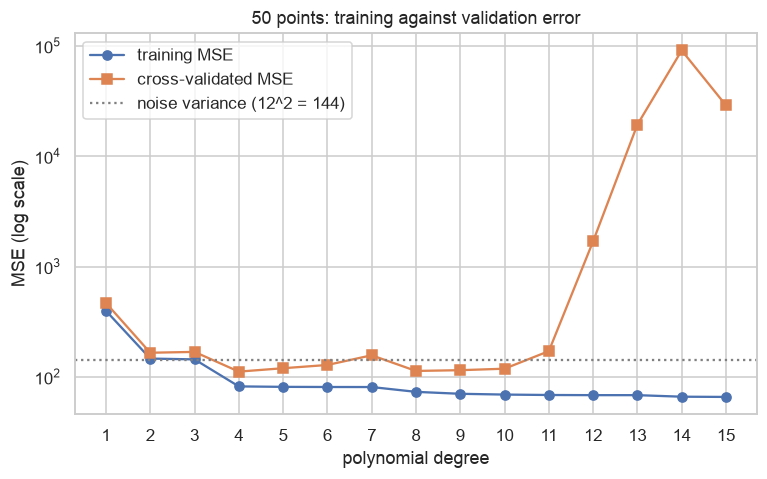

    train_mse      cv_mse         gap
1    397.9000    468.5000     70.6000
2    146.9000    165.9000     19.0000
3    144.4000    168.8000     24.4000
4     82.2000    111.9000     29.7000
5     81.4000    120.1000     38.7000
6     81.1000    128.5000     47.4000
7     81.1000    157.3000     76.3000
8     73.3000    113.5000     40.1000
9     70.4000    115.3000     44.8000
10    69.3000    118.9000     49.6000
11    68.7000    171.5000    102.8000
12    68.4000  1,699.1000  1,630.6000
13    68.4000 19,405.7000 19,337.3000
14    66.3000 91,266.8000 91,200.5000
15    66.0000 28,992.7000 28,926.8000

500 points:
    train_mse   cv_mse     gap
1    339.2000 341.5000  2.3000
2    176.1000 178.2000  2.1000
3    176.1000 179.8000  3.6000
4    137.3000 140.5000  3.2000
5    136.9000 140.7000  3.8000
6    136.5000 141.0000  4.5000
7    136.3000 141.2000  4.9000
8    136.1000 143.1000  6.9000
9    136.1000 143.2000  7.1000
10   135.6000 143.7000  8.1000
11   135.5000 144.8000  9.3000
12   13

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(_sweep.index, _sweep["train_mse"], marker="o", label="training MSE")
ax.plot(_sweep.index, _sweep["cv_mse"], marker="s", label="cross-validated MSE")
ax.axhline(12.0 ** 2, color="grey", linestyle=":", label="noise variance (12^2 = 144)")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE (log scale)")
ax.set_title("50 points: training against validation error")
ax.set_xticks(list(_sweep.index))
ax.legend()
plt.show()
print((_sweep.assign(gap=_sweep["cv_mse"] - _sweep["train_mse"])).round(1).to_string())

_big_rng = np.random.default_rng(SEED)
_x_big = _big_rng.uniform(-3, 3, 500)
_y_big = (_x_big ** 4 - 3 * _x_big ** 2 + _x_big + 5) + _big_rng.normal(0, 12.0, 500)
_sweep_big = degree_sweep(_x_big, _y_big, range(1, 16), KFold(5, shuffle=True, random_state=SEED))
print("\n500 points:")
print((_sweep_big.assign(gap=_sweep_big["cv_mse"] - _sweep_big["train_mse"])).round(1).to_string())
print(f"best degree: 50 points -> {_sweep['cv_mse'].idxmin()}, 500 points -> {_sweep_big['cv_mse'].idxmin()}")
for name, sweep in [("50", _sweep), ("500", _sweep_big)]:
    best = sweep["cv_mse"].min()
    within = sweep.index[sweep["cv_mse"] <= 1.1 * best].tolist()
    print(f"{name} points: degrees within 10% of the best CV MSE: {within}; "
          f"CV MSE at degree 15 is {sweep.loc[15, 'cv_mse'] / best:.1f} x the best")

**Your answer:**

**(a)** The noise variance is 12² = 144.
- **Underfitting (degrees 1 to 3).** Training and validation errors are both high: training MSE 397.9 / 146.9 / 144.4, CV MSE 468.5 / 165.9 / 168.8. The gap between them is small (19 to 71). A curve of degree below 4 cannot follow a quartic, so the model is wrong in the same way on the training and on the validation data.
- **Best (degree 4).** The best CV MSE is 111.9, and training MSE drops to 82.2.
- **Overfitting (from degree 11, clearly from 12).** Training MSE keeps falling slightly (68.7, 68.4, 68.4, 66.3, 66.0), but CV MSE explodes: 171.5 at degree 11, 1 699 at 12, 19 406 at 13 and 91 267 at 14. The gap grows from about 30 to more than 90 000.

The gap is the diagnostic because each curve alone is ambiguous. A falling training error looks like "better" at every degree, and a high validation error could mean either underfitting or overfitting. The combination tells them apart: both errors high with a small gap means underfitting (the model is too simple even for the training data), and a low training error with a large gap means overfitting (the model has learnt the training points, including their noise, and does not generalise).

**(b)** As the degree approaches the number of points (50), the training MSE tends to 0. A polynomial of degree n − 1 has n coefficients, so it can pass exactly through all n points and interpolate them, noise included. Already at degree 15 the training MSE (66.0) is far below the noise variance of 144, which means the model is fitting the noise. The validation MSE goes the other way and becomes huge and unstable (91 267 at degree 14, 28 993 at 15, jumping around): between and beyond the training points, a high-degree polynomial swings wildly, and small changes in which points are in the fold change its shape completely.

**(c)** With 500 points and the same noise, degree 4 still wins (CV MSE 140.5, close to the noise variance 144). But the overfitting region has moved far to the right. The gap stays small up to about degree 12 (2.1 to 12.8). Degrees 4 to 12 are all within 10 % of the best CV MSE, compared with only degrees 4, 5, 8, 9 and 10 with 50 points. Even degree 15 is only 1.2 times the best, against 259 times with 50 points. The general relationship: the more data you have, the more complex a model you can afford before it starts fitting the noise. With few points only a simple model is safe, and every extra parameter needs enough data to be estimated reliably.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [16]:
def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None), criteria=("gini", "entropy")):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
        'best_depth'      the chosen max_depth (may be None)
        'best_criterion'  the chosen criterion, a string
        'best_cv_score'   the best cross-validated accuracy, a float
        'search'          the fitted GridSearchCV object
    """
    search = GridSearchCV(
        DecisionTreeClassifier(random_state=SEED),
        {"max_depth": list(depths), "criterion": list(criteria)},
        cv=cv, scoring="accuracy", refit=True,
    ).fit(X, y)
    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search,
    }

In [17]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

In [18]:
_q4_results = pd.DataFrame(_tuned["search"].cv_results_)
_q4_results["max_depth"] = _q4_results["param_max_depth"].astype(object).fillna("None").astype(str)
_q4_table = _q4_results.pivot(index="max_depth", columns="param_criterion", values="mean_test_score")
_q4_order = ["1", "2", "3", "4", "5", "6", "8", "10", "None"]
print("mean CV accuracy:")
print(_q4_table.reindex(_q4_order).round(4).to_string())

print("\ntraining accuracy and leaves at each depth (gini, fitted on all 150 flowers):")
for depth in (1, 2, 3, 4, 5, 6, 8, 10, None):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(_X_iris, _y_iris)
    print(f"  max_depth {str(depth):>4}: train {tree.score(_X_iris, _y_iris):.4f}  leaves {tree.get_n_leaves()}")

_q4_full = DecisionTreeClassifier(max_depth=None, random_state=SEED).fit(_X_iris, _y_iris)
print(f"\nmax_depth=None: training accuracy {_q4_full.score(_X_iris, _y_iris):.4f}, "
      f"leaves {_q4_full.get_n_leaves()}, depth {_q4_full.get_depth()}, CV {_full:.4f}")
for min_leaf in (1, 5, 10, 20):
    tree = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=SEED)
    cv_score = cross_val_score(tree, _X_iris, _y_iris, cv=_iris_cv).mean()
    tree.fit(_X_iris, _y_iris)
    print(f"  min_samples_leaf {min_leaf:2}: train {tree.score(_X_iris, _y_iris):.4f}  "
          f"leaves {tree.get_n_leaves():2}  CV {cv_score:.4f}")

def _impurity(counts, criterion):
    p = np.array(counts) / sum(counts)
    p = p[p > 0]
    return 1 - np.sum(p ** 2) if criterion == "gini" else -np.sum(p * np.log2(p))

def _gain(parent, left, criterion):
    right = [a - b for a, b in zip(parent, left)]
    n = sum(parent)
    return (_impurity(parent, criterion) - sum(left) / n * _impurity(left, criterion)
            - sum(right) / n * _impurity(right, criterion))

print("\nparent node 50/50; impurity decrease of two candidate splits:")
for name, left in [("A: left child 0/15 (pure)", [0, 15]), ("B: left child 5/25", [5, 25])]:
    print(f"  {name:26s} gini {_gain([50, 50], left, 'gini'):.4f}   entropy {_gain([50, 50], left, 'entropy'):.4f}")

mean CV accuracy:
param_criterion  entropy   gini
max_depth                      
1                 0.6667 0.6667
2                 0.9200 0.9200
3                 0.9200 0.9200
4                 0.9333 0.9333
5                 0.9333 0.9333
6                 0.9333 0.9333
8                 0.9333 0.9333
10                0.9333 0.9333
None              0.9333 0.9333

training accuracy and leaves at each depth (gini, fitted on all 150 flowers):
  max_depth    1: train 0.6667  leaves 2
  max_depth    2: train 0.9600  leaves 3
  max_depth    3: train 0.9733  leaves 5
  max_depth    4: train 0.9933  leaves 8
  max_depth    5: train 1.0000  leaves 9
  max_depth    6: train 1.0000  leaves 9
  max_depth    8: train 1.0000  leaves 9
  max_depth   10: train 1.0000  leaves 9
  max_depth None: train 1.0000  leaves 9

max_depth=None: training accuracy 1.0000, leaves 9, depth 5, CV 0.9333
  min_samples_leaf  1: train 1.0000  leaves  9  CV 0.9333
  min_samples_leaf  5: train 0.9733  leaves  6  CV 0

**Your answer:**

**(a)** Mean CV accuracy on Iris (5 folds):

| max_depth | 1 | 2 | 3 | 4 | 5 | 6 | 8 | 10 | None |
|---|---|---|---|---|---|---|---|---|---|
| gini | 0.6667 | 0.9200 | 0.9200 | 0.9333 | 0.9333 | 0.9333 | 0.9333 | 0.9333 | 0.9333 |
| entropy | 0.6667 | 0.9200 | 0.9200 | 0.9333 | 0.9333 | 0.9333 | 0.9333 | 0.9333 | 0.9333 |

**Small depth is underfitting, large depth is overfitting.** Depth 1 clearly underfits: a stump has 2 leaves for 3 classes, so it can separate setosa but not versicolor from virginica, which gives 0.667 on both training and CV. At depth 2 or 3 the score jumps to 0.92, and the best is 0.9333 from depth 4. Overfitting starts at depth 5 on this data: that is where the training accuracy reaches 1.0000 (0.9933 at depth 4) with 9 leaves, i.e. the tree starts making leaves for individual training points. On Iris this does not lower the CV score, which stays at 0.9333. The fully grown tree only reaches depth 5 anyway, so depths 5, 6, 8, 10 and None are the same tree. The extra leaves just do not help. On noisier data the CV score would fall at this point, so the smallest depth with the best score (4) is the one to choose.

**(b)** Both measure how mixed the classes in a node are. Gini impurity is 1 − Σ pₖ², the probability that two randomly drawn samples from the node belong to different classes. Entropy is −Σ pₖ log₂ pₖ, the amount of information (in bits) needed to know the class. Both are 0 for a pure node and maximal for a 50/50 mix, and as functions of p they have almost the same shape. So they rank candidate splits almost always the same way, and here they gave exactly the same score at every depth. They can disagree when a split creates a small pure node. Entropy rewards purity more strongly, because −p log p rises steeply near p = 0. My example: parent node with 50/50 classes. Split A puts 15 samples of one class into a pure left child (0/15). Split B puts 5/25 into the left child. Gini prefers B (decrease 0.0952 against 0.0882), entropy prefers A (0.1692 against 0.1468).

**(c)** With `max_depth=None` the tree reaches a training accuracy of 1.0000 (9 leaves, depth 5). That number tells us nothing, because an unconstrained tree keeps splitting until every leaf is pure, so it will always be (almost) 100 % on the data it was grown on, whether or not it generalises. The other hyperparameter from Practice 3 §8.3 is `min_samples_leaf`. It forbids leaves with fewer than n samples, so it limits the tree from below (leaf size) instead of from above (depth). With `min_samples_leaf=5` the training accuracy drops to 0.9733 with 6 leaves (CV 0.9200).

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [19]:
def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.

    Return a dict with exactly these five keys:
        'cv_scores'         a 1-D array of mean CV accuracy, one per k
        'best_k_cv'         the k chosen by cross-validation
        'test_accuracy'     the honest test accuracy of that k
        'best_k_peeking'    the k that maximises test accuracy
        'peeking_accuracy'  that k's test accuracy (an optimistic number)
    """
    ks = list(k_values)

    def pipeline(k):
        return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))

    cv_scores = np.array([cross_val_score(pipeline(k), X_train, y_train, cv=cv).mean() for k in ks])
    best_k_cv = ks[int(np.argmax(cv_scores))]
    test_accuracy = pipeline(best_k_cv).fit(X_train, y_train).score(X_test, y_test)

    test_scores = np.array([pipeline(k).fit(X_train, y_train).score(X_test, y_test) for k in ks])
    best_k_peeking = ks[int(np.argmax(test_scores))]
    return {
        "cv_scores": cv_scores,
        "best_k_cv": best_k_cv,
        "test_accuracy": float(test_accuracy),
        "best_k_peeking": best_k_peeking,
        "peeking_accuracy": float(test_scores.max()),
    }

In [20]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

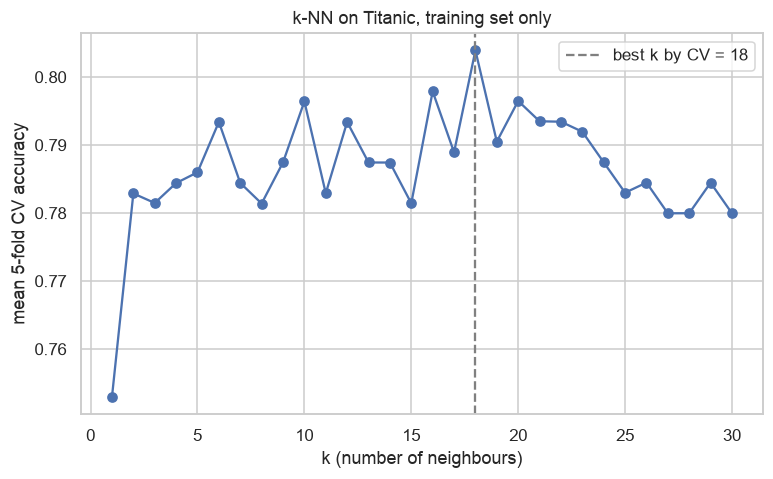

best CV accuracy 0.8039 at k = 18
survival rate: all passengers 0.3838, training set 0.3832, test set 0.3857
CV accuracy at k = 1, 5, 10, 20, 30: [0.753, 0.786, 0.7964, 0.7965, 0.78]
k =   1: training accuracy 0.9820  test accuracy 0.7803
k = 668: training accuracy 0.6168  test accuracy 0.6143
majority-class share in the training set: 0.6168


k in 1..30 : CV picks k= 18 -> test 0.8206;  peeking picks k= 25 -> 0.8520;  optimism +0.0314
k in 1..200: CV picks k= 18 -> test 0.8206;  peeking picks k= 25 -> 0.8520;  optimism +0.0314



test_size 0.10: train 801, test 90, best k 20, honest test accuracy 0.8333, one test row is worth 0.0111


test_size 0.25: train 668, test 223, best k 18, honest test accuracy 0.8206, one test row is worth 0.0045


test_size 0.40: train 534, test 357, best k  8, honest test accuracy 0.8095, one test row is worth 0.0028


In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, 31), _sel["cv_scores"], marker="o")
ax.axvline(_sel["best_k_cv"], color="grey", linestyle="--", label=f"best k by CV = {_sel['best_k_cv']}")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("mean 5-fold CV accuracy")
ax.set_title("k-NN on Titanic, training set only")
ax.legend()
plt.show()
print(f"best CV accuracy {_sel['cv_scores'].max():.4f} at k = {_sel['best_k_cv']}")
print(f"survival rate: all passengers {_y_knn.mean():.4f}, training set {_yk_tr.mean():.4f}, test set {_yk_te.mean():.4f}")
print("CV accuracy at k = 1, 5, 10, 20, 30:",
      [round(float(_sel["cv_scores"][k - 1]), 4) for k in (1, 5, 10, 20, 30)])

for k in (1, len(_Xk_tr)):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(_Xk_tr, _yk_tr)
    print(f"k = {k:3}: training accuracy {model.score(_Xk_tr, _yk_tr):.4f}  "
          f"test accuracy {model.score(_Xk_te, _yk_te):.4f}")
print(f"majority-class share in the training set: {max(_yk_tr.mean(), 1 - _yk_tr.mean()):.4f}")

_sel_200 = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 201), _k_cv)
for name, sel in [("k in 1..30 ", _sel), ("k in 1..200", _sel_200)]:
    print(f"{name}: CV picks k={sel['best_k_cv']:3} -> test {sel['test_accuracy']:.4f};  "
          f"peeking picks k={sel['best_k_peeking']:3} -> {sel['peeking_accuracy']:.4f};  "
          f"optimism {sel['peeking_accuracy'] - sel['test_accuracy']:+.4f}")

print()
for test_size in (0.1, 0.25, 0.4):
    Xa, Xb, ya, yb = train_test_split(_X_knn, _y_knn, test_size=test_size, random_state=SEED, stratify=_y_knn)
    sel = honest_k_selection(Xa, ya, Xb, yb, range(1, 31), _k_cv)
    print(f"test_size {test_size:.2f}: train {len(ya)}, test {len(yb)}, best k {sel['best_k_cv']:2}, "
          f"honest test accuracy {sel['test_accuracy']:.4f}, "
          f"one test row is worth {1 / len(yb):.4f}")

**Your answer:**

**(a)** In the plot of CV accuracy against k, the score is lowest at k = 1 (0.753), rises quickly (0.786 at k = 5, around 0.79–0.80 for k = 10 to 20) and peaks at k = 18 (0.804), then slowly falls towards 0.780 at k = 30. **Small k is overfitting, large k is underfitting.** At k = 1 each prediction copies the label of the single nearest training passenger. The training accuracy is 0.9820 (each training point is its own nearest neighbour, except for duplicate points with different labels), but the CV accuracy is only 0.753 and the test accuracy 0.780. The model memorises the training noise. At k = len(X_train) = 668, every prediction is a vote of the entire training set, so the model always predicts the majority class ("died"). The training accuracy is 0.6168, exactly the majority share, and the test accuracy is 0.6143, the baseline. The model ignores the features completely. Between the two extremes, a larger k averages over more neighbours: less variance and more bias.

**(b)** Choosing k by CV gives k = 18 with an honest test accuracy of 0.8206. Choosing by the test set gives k = 25 with 0.8520, which is +0.0314 higher. The peeking number is biased upwards because every test accuracy is a noisy measurement: with 223 test rows each row is worth 0.0045, so the scores for different k differ partly by luck in which test passengers happen to be classified right. Taking the maximum of 30 noisy numbers selects the k whose noise happened to be most positive, so the maximum is on average higher than the true accuracy of that k. It is no longer an independent estimate, because the test set was used to make the choice. With more candidates the expected maximum of the noise grows, so in general the bias gets bigger when k goes from 1 to 200. In my test, it stayed the same: both CV and peeking chose the same k as before (18 and 25), and the optimism is still +0.0314, because none of the extra k from 31 to 200 happened to get a higher test score than 0.8520. So on this split the extra candidates did not add bias, but they could only have increased it, never decreased it.

**(c)** With the same seed and a stratified split:

| test_size | training rows | test rows | best k | honest test accuracy | one test row worth |
|---|---|---|---|---|---|
| 0.10 | 801 | 90 | 20 | 0.8333 | 0.0111 |
| 0.25 | 668 | 223 | 18 | 0.8206 | 0.0045 |
| 0.40 | 534 | 357 | 8 | 0.8095 | 0.0028 |

A larger test set makes the test estimate more precise (each row matters less, so the number moves less from one split to another), but it leaves less data to train and tune on, so the model itself is a bit worse, and the CV choice of k is based on fewer rows. A small test set gives a better model but a noisy estimate: 0.8333 on 90 passengers is only ±1 passenger per 0.011. The differences in the table (0.83 to 0.81) are of the same order as this noise. `stratify=` makes the test and training sets have the same share of survivors as the whole data (38.4 %). Practice 3 §5.3 showed that without it the survival rate in a random test set moves by several percentage points depending on the seed alone. That would change the baseline and the accuracy just by luck of the split, and any comparison smaller than that would measure the split rather than the model.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [22]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is  w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """
    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]
    w1, w2 = svc.coef_[0]
    b = svc.intercept_[0]
    mu_x, mu_y = scaler.mean_
    s_x, s_y = scaler.scale_
    if abs(w2) < 1e-12:
        raise ValueError("the boundary is vertical, so it cannot be written as y = slope * x + intercept")
    slope = -(s_y / w2) * (w1 / s_x)
    intercept = mu_y - (s_y / w2) * (b - w1 * mu_x / s_x)
    return float(slope), float(intercept)

In [23]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 2.80e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

linear kernel:
  C =   0.001: support vectors 600  margin width 4.9368  train 0.8350  CV 0.8317
  C =       1: support vectors  74  margin width 0.4146  train 0.9717  CV 0.9717
  C =    1000: support vectors  46  margin width 0.2189  train 0.9733  CV 0.9717

RBF kernel, C = 1:
  gamma =  0.01: support vectors 284  train 0.9600  CV 0.9650
  gamma =     1: support vectors  86  train 0.9733  CV 0.9683
  gamma =   100: support vectors 487  train 0.9850  CV 0.9550

linear, C=1        : CV 0.9717 +/- 0.0085
rbf, C=1, gamma=scale: CV 0.9683 +/- 0.0097
one test point in a fold of 120 is worth 0.0083


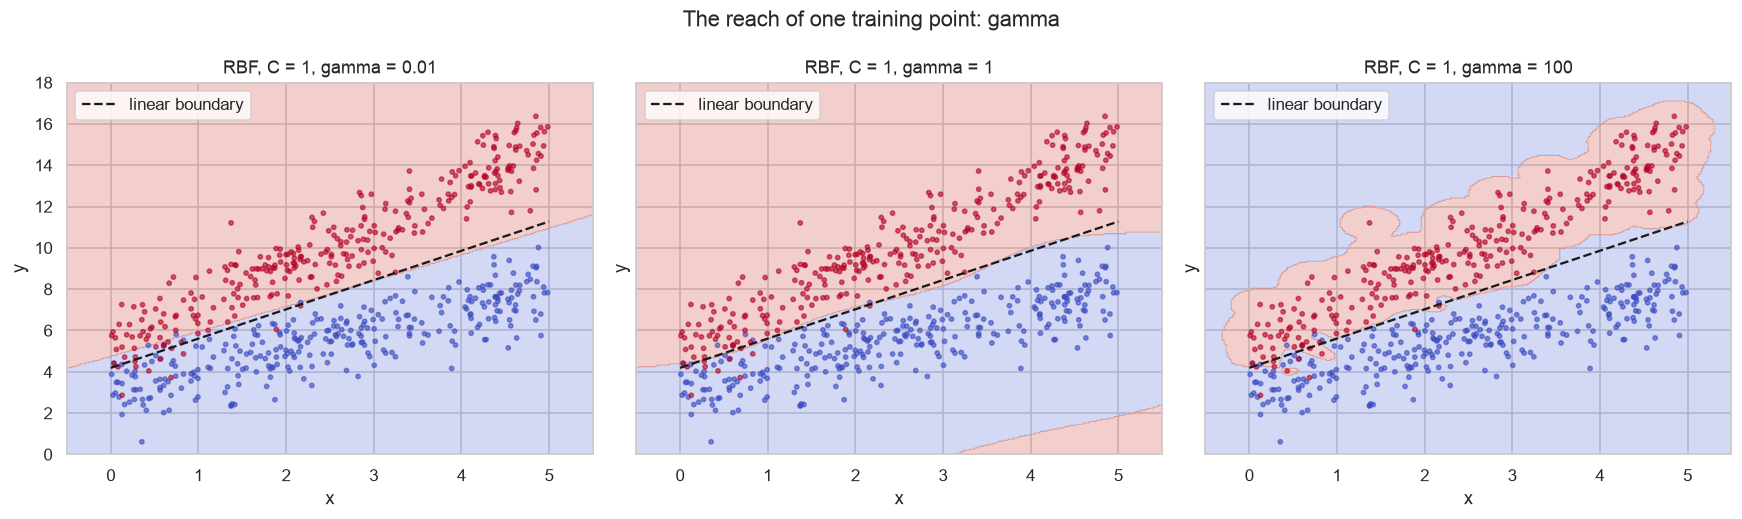

In [24]:
_q6_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
print("linear kernel:")
for C in (0.001, 1, 1000):
    model = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C, random_state=SEED)).fit(_X_two, _y_two)
    svc = model.named_steps["svc"]
    cv_score = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="linear", C=C, random_state=SEED)),
                               _X_two, _y_two, cv=_q6_cv).mean()
    print(f"  C = {C:>7}: support vectors {int(svc.n_support_.sum()):3}  "
          f"margin width {2 / np.linalg.norm(svc.coef_):.4f}  "
          f"train {model.score(_X_two, _y_two):.4f}  CV {cv_score:.4f}")

print("\nRBF kernel, C = 1:")
_q6_models = {}
for gamma in (0.01, 1, 100):
    estimator = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=gamma, random_state=SEED))
    cv_score = cross_val_score(estimator, _X_two, _y_two, cv=_q6_cv).mean()
    _q6_models[gamma] = estimator.fit(_X_two, _y_two)
    print(f"  gamma = {gamma:>5}: support vectors {int(estimator.named_steps['svc'].n_support_.sum()):3}  "
          f"train {estimator.score(_X_two, _y_two):.4f}  CV {cv_score:.4f}")

_q6_linear_cv = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED)),
                                _X_two, _y_two, cv=_q6_cv)
_q6_rbf_cv = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)),
                             _X_two, _y_two, cv=_q6_cv)
print(f"\nlinear, C=1        : CV {_q6_linear_cv.mean():.4f} +/- {_q6_linear_cv.std():.4f}")
print(f"rbf, C=1, gamma=scale: CV {_q6_rbf_cv.mean():.4f} +/- {_q6_rbf_cv.std():.4f}")
print(f"one test point in a fold of {len(_y_two) // 5} is worth {1 / (len(_y_two) // 5):.4f}")

_gx, _gy = np.meshgrid(np.linspace(-0.5, 5.5, 300), np.linspace(0, 18, 300))
_grid = np.column_stack([_gx.ravel(), _gy.ravel()])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
for ax, (gamma, model) in zip(axes, _q6_models.items()):
    ax.contourf(_gx, _gy, model.predict(_grid).reshape(_gx.shape), alpha=0.25, cmap="coolwarm")
    ax.scatter(_X_two[:, 0], _X_two[:, 1], c=_y_two, cmap="coolwarm", s=8, alpha=0.6)
    ax.plot([0, 5], [_slope * 0 + _intercept, _slope * 5 + _intercept], "k--", linewidth=1.5,
            label="linear boundary")
    ax.set_title(f"RBF, C = 1, gamma = {gamma}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper left")
fig.suptitle("The reach of one training point: gamma")
fig.tight_layout()
plt.show()

**Your answer:**

**(a)** Linear kernel on the two-line data:

| C | support vectors | margin width (scaled space) | training accuracy | CV accuracy |
|---|---|---|---|---|
| 0.001 | 600 | 4.9368 | 0.8350 | 0.8317 |
| 1 | 74 | 0.4146 | 0.9717 | 0.9717 |
| 1000 | 46 | 0.2189 | 0.9733 | 0.9717 |

**Small C is underfitting, large C is overfitting.** C is the price of a margin violation. With C = 0.001 violations are almost free, so the SVM chooses a very wide margin (4.94) that contains all 600 points, every point is a support vector, and the boundary is badly placed (0.835 on training and on CV). With C = 1000 violations are expensive, so the margin shrinks to 0.22 and only 46 points define it. The boundary is pushed to classify every training point correctly (training 0.9733), which means it is fitted to the noisy points near the boundary. On this data that did not reduce the CV score (0.9717, the same as C = 1), because the classes are close to linearly separable, but the direction is towards overfitting.

**(b)** RBF kernel, C = 1:

| gamma | support vectors | training accuracy | CV accuracy |
|---|---|---|---|
| 0.01 | 284 | 0.9600 | 0.9650 |
| 1 | 86 | 0.9733 | 0.9683 |
| 100 | 487 | 0.9850 | 0.9550 |

`gamma` sets how far the influence of one training point reaches: the kernel is exp(−gamma · distance²), so a small gamma means each point affects a large area, and a large gamma means only its immediate neighbourhood. At gamma = 0.01 the reach is so large that the boundary is smooth and almost a straight line, close to the linear boundary (slightly underfit, CV 0.965). At gamma = 1 the boundary follows the data a bit more and is still smooth (CV 0.968), though far from the data it shows a strange extra class-1 region in the bottom right corner, where there are no training points. At gamma = 100 each point only influences a tiny area around itself. The class-1 region becomes a chain of small "islands" drawn around the red training points, and everything else, including the empty space above the data, is assigned to class 0. This extreme memorises the training points: the training accuracy is the highest (0.985), CV is the lowest (0.955), and 487 of 600 points are support vectors.

**(c)** No, not meaningfully. Linear C = 1 gives CV 0.9717 ± 0.0085, and RBF with gamma = "scale" gives 0.9683 ± 0.0097. The linear one is even slightly better, but the difference (0.0034) is smaller than the SD across folds, and smaller than one point in a validation fold of 120 (0.0083). The data were generated from two straight lines with noise, so the true boundary is a line, and a linear kernel already contains it. RBF can represent a line too, but it adds flexibility that is useless here and only gives it more room to fit noise (as gamma = 100 showed), and it costs an extra hyperparameter to tune. The general principle is to start with the simplest model that can represent the problem and move to a more flexible kernel only if cross-validation shows a real improvement, larger than the fold-to-fold noise.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [25]:
def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'      KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
        'silhouette'   silhouette_score of that KMeans labelling
        'bic'          GaussianMixture(n_components=k, covariance_type='full',
                       random_state=SEED).bic(X)
        'aic'          the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """
    rows = {}
    for k in k_values:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED).fit(X)
        rows[k] = {
            "inertia": kmeans.inertia_,
            "silhouette": silhouette_score(X, kmeans.labels_),
            "bic": gmm.bic(X),
            "aic": gmm.aic(X),
        }
    return pd.DataFrame(rows).T[["inertia", "silhouette", "bic", "aic"]]

In [26]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [27]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


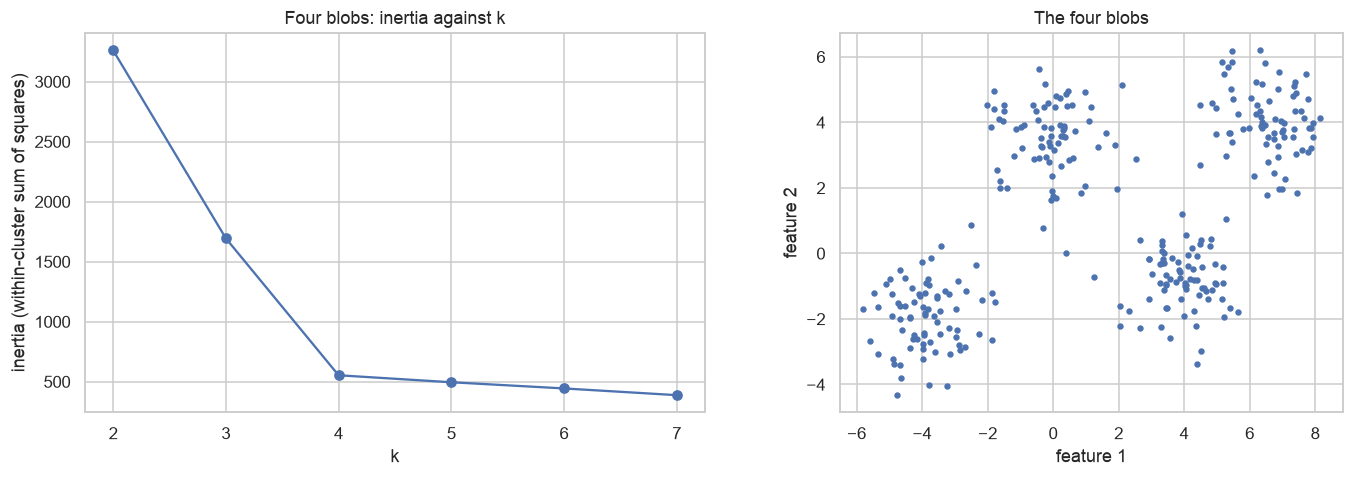

inertia drop from k to k+1: {3: 1566.4, 4: 1141.2, 5: 58.2, 6: 51.5, 7: 56.1}



harder data:
     inertia  silhouette        bic        aic
2 7,175.0020      0.5160 8,512.4190 8,459.5920
3 4,690.2510      0.4230 8,410.6690 8,329.0280
4 3,470.1580      0.4280 8,451.9990 8,341.5440
5 2,822.5210      0.4040 8,490.5460 8,351.2760
6 2,355.3400      0.3660 8,526.4190 8,358.3360
7 1,994.2770      0.3680 8,559.2670 8,362.3680
silhouette -> 2,  BIC -> 3,  AIC -> 3,  truth -> 3
k = 2: ARI k-means 0.4463, ARI GMM full 0.4519
k = 3: ARI k-means 0.4606, ARI GMM full 0.6407


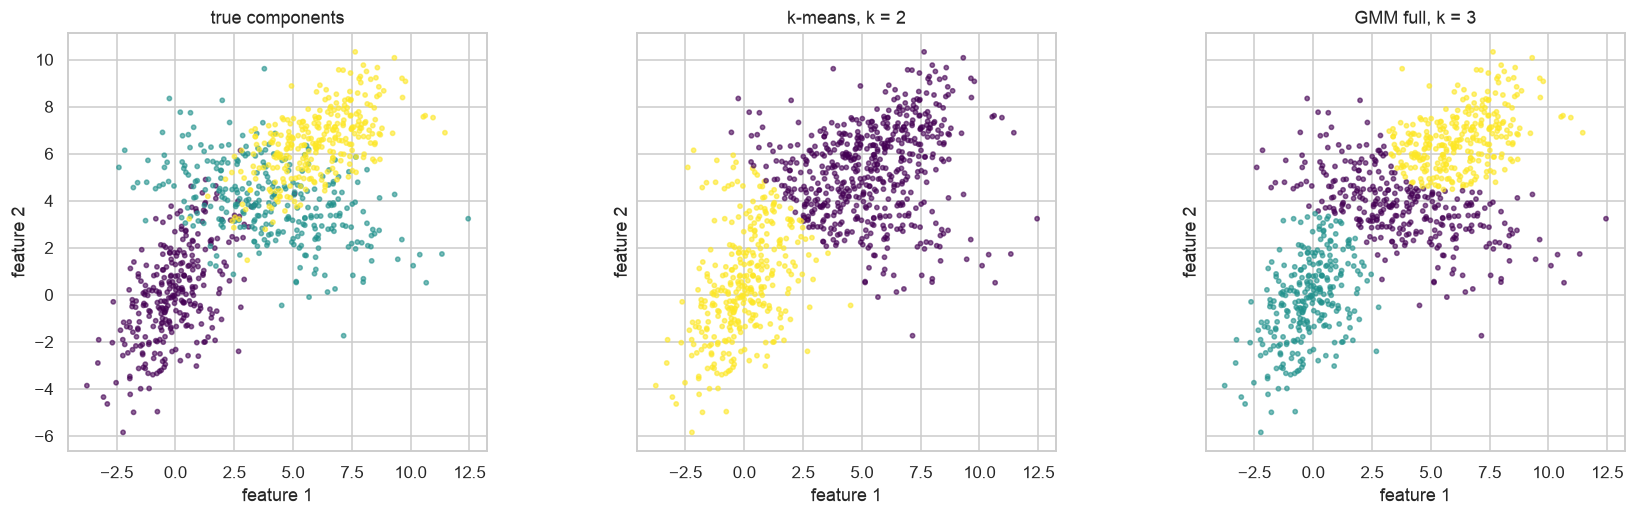


init=k-means++ n_init=1, random_state 0..9: inertia min 4690.3  max 4692.7  range 2.5  distinct solutions 3
    [4691.9 4690.3 4690.3 4691.9 4691.9 4691.9 4691.9 4692.7 4691.9 4690.3]


init=random    n_init=1, random_state 0..9: inertia min 4690.2  max 4691.9  range 1.7  distinct solutions 4
    [4691.4 4691.9 4691.9 4691.9 4691.9 4690.3 4691.9 4690.3 4691.9 4690.2]
n_init=10 (default k-means++): inertia 4690.3

k-means, k=3                : ARI 0.4606
GMM covariance_type=full     : ARI 0.6407  parameters 17  BIC 8410.7
GMM covariance_type=tied     : ARI 0.4493  parameters 11  BIC 8561.7
GMM covariance_type=diag     : ARI 0.4362  parameters 14  BIC 8544.7
GMM covariance_type=spherical: ARI 0.4527  parameters 11  BIC 8576.1


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(_scores.index, _scores["inertia"], marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia (within-cluster sum of squares)")
axes[0].set_title("Four blobs: inertia against k")
axes[1].scatter(_X_blobs[:, 0], _X_blobs[:, 1], s=10)
axes[1].set_xlabel("feature 1")
axes[1].set_ylabel("feature 2")
axes[1].set_title("The four blobs")
axes[1].set_aspect("equal")
fig.tight_layout()
plt.show()
print("inertia drop from k to k+1:", (-_scores["inertia"].diff()).dropna().round(1).to_dict())

_hard_scores = cluster_selection(X_hard, range(2, 8))
print("\nharder data:")
print(_hard_scores.round(3).to_string())
print(f"silhouette -> {_hard_scores['silhouette'].idxmax()},  BIC -> {_hard_scores['bic'].idxmin()},  "
      f"AIC -> {_hard_scores['aic'].idxmin()},  truth -> 3")
for k in (2, 3):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_hard)
    gm = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED).fit(X_hard)
    print(f"k = {k}: ARI k-means {adjusted_rand_score(y_hard, km.labels_):.4f}, "
          f"ARI GMM full {adjusted_rand_score(y_hard, gm.predict(X_hard)):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
_hard_panels = [
    ("true components", y_hard),
    ("k-means, k = 2", KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(X_hard)),
    ("GMM full, k = 3", GaussianMixture(n_components=3, random_state=SEED).fit(X_hard).predict(X_hard)),
]
for ax, (title, labels) in zip(axes, _hard_panels):
    ax.scatter(X_hard[:, 0], X_hard[:, 1], c=labels, cmap="viridis", s=8, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print()
for init in ("k-means++", "random"):
    inertias = np.array([KMeans(n_clusters=3, n_init=1, init=init, random_state=s).fit(X_hard).inertia_
                         for s in range(10)])
    print(f"init={init:9s} n_init=1, random_state 0..9: inertia min {inertias.min():.1f}  "
          f"max {inertias.max():.1f}  range {inertias.max() - inertias.min():.1f}  "
          f"distinct solutions {len(np.unique(inertias.round(1)))}")
    print("   ", inertias.round(1))
print(f"n_init=10 (default k-means++): inertia {KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_hard).inertia_:.1f}")

print()
_km3 = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_hard)
print(f"k-means, k=3                : ARI {adjusted_rand_score(y_hard, _km3.labels_):.4f}")
for covariance_type in ("full", "tied", "diag", "spherical"):
    gm = GaussianMixture(n_components=3, covariance_type=covariance_type, random_state=SEED).fit(X_hard)
    print(f"GMM covariance_type={covariance_type:9s}: ARI {adjusted_rand_score(y_hard, gm.predict(X_hard)):.4f}  "
          f"parameters {int(gm._n_parameters()):2}  BIC {gm.bic(X_hard):.1f}")

**Your answer:**

**(a)** On the four blobs the inertia is 3 260.9 at k = 2, 1 694.5 at 3, 553.4 at 4, 495.2 at 5, 443.7 at 6 and 387.6 at 7. It keeps falling at every k. Inertia is the sum of squared distances of points to their cluster centre, and adding a cluster can only move some points closer to a centre. At k = n (one cluster per point) it would be 0. So minimising it always chooses the largest k and says nothing about the real structure. The "elbow" is the k after which extra clusters only give small improvements: the point where the curve stops falling steeply and starts falling slowly, meaning that the remaining decrease only comes from splitting real groups. On my plot the elbow is very clear. The drops are 1 566 (2 → 3) and 1 141 (3 → 4), and then only 58, 52 and 56. So I am confident it is 4 here, which matches the silhouette (0.697 at k = 4) and BIC. But this is an easy case with four round, well-separated blobs. On the harder data the inertia curve (7 175, 4 690, 3 470, 2 823, …) has no clear elbow at all, and reading it would be mostly guessing.

**(b)** On the harder data the silhouette chooses k = 2 (0.516, against 0.423 at k = 3), while BIC and AIC both choose k = 3 (BIC 8 410.7 at k = 3, against 8 512.4 at k = 2). The truth is 3, so BIC is right. The silhouette measures, for each point, how much closer it is to its own cluster than to the nearest other cluster, so it rewards compact, well-separated, round clusters. Components 2 and 3 overlap heavily, so putting them together in one cluster gives two groups that are more clearly separated from each other than three clusters would be. The silhouette therefore prefers 2. It answers its own question (are the clusters compact and separated?) correctly, but that is not the question of how many components generated the data. BIC uses the likelihood of a Gaussian mixture with full covariance and penalises the number of parameters. The three tilted, elongated components fit that model well, so it finds 3. The GMM with 3 components also recovers the true labels much better: ARI 0.6407, against 0.4606 for k-means with k = 3.

**(c)** With `n_init=1` and random_state 0 to 9 (k = 3), the inertia varies only a little: with `init='k-means++'` it ranges from 4 690.3 to 4 692.7 (range 2.5, 3 different solutions), and with `init='random'` from 4 690.2 to 4 691.9 (range 1.7, 4 different solutions). k-means only finds a local minimum, and the result depends on the starting centres. `n_init` runs the algorithm several times from different starting points and keeps the solution with the lowest inertia. With `n_init=10` I get 4 690.3, the best of the local optima. `init='k-means++'` chooses the initial centres spread out, each new one far from those already chosen (with probability proportional to squared distance), instead of choosing them completely at random. That makes it less likely to start with two centres in the same group, so it usually converges faster and to a better solution. On this data the differences between the solutions are small (well under 0.1 % of the inertia), because the problem has a few similar local optima, but with more clusters or badly separated data a single run can end up far from the best solution.

**(d)** GMM with 3 components, ARI against the true labels:
- `full` (each component has its own complete covariance matrix, any size, shape and orientation): 0.6407, 17 parameters, the best BIC (8 410.7);
- `tied` (all components share one covariance matrix, same shape and orientation): 0.4493;
- `diag` (each component has its own variances, but its axes are aligned with the coordinate axes, no tilt): 0.4362;
- `spherical` (each component is a circle, one variance per component): 0.4527.

k-means with k = 3 gets 0.4606. Only `full` can describe components that are tilted in different directions, as they are here, which is why it is clearly the best. k-means assigns each point to the nearest centre by Euclidean distance. That is the same as assuming round clusters of equal size, so the `spherical` model is the one that reproduces k-means' behaviour (ARI 0.4527, close to k-means' 0.4606). It is not exactly the same, because spherical components can still have different variances and soft assignments.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

In [29]:
from sklearn.dummy import DummyRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

one_hot = ["season", "mnth", "hr", "weekday", "weathersit"]
binary = ["yr", "holiday", "workingday"]
numeric = ["temp", "hum", "windspeed"]
features = pd.get_dummies(bikes[one_hot].astype("category"), dtype=int)
features[binary] = bikes[binary]
features[numeric] = bikes[numeric]
X_bike = features.values.astype(float)
y_bike = bikes["cnt"].values.astype(float)
print("features:", X_bike.shape, "| excluded: instant, dteday, atemp, casual, registered")

X_dev, X_test, y_dev, y_test = train_test_split(X_bike, y_bike, test_size=0.2, random_state=SEED)
print(f"development {X_dev.shape[0]} rows, test {X_test.shape[0]} rows (put away until step 6)")

bike_cv = KFold(5, shuffle=True, random_state=SEED)
scoring = {"rmse": "neg_root_mean_squared_error", "r2": "r2"}

def cv_report(name, estimator):
    start = time.perf_counter()
    scores = cross_validate(estimator, X_dev, y_dev, cv=bike_cv, scoring=scoring)
    rmse, r2 = -scores["test_rmse"], scores["test_r2"]
    return {"model": name, "rmse_mean": rmse.mean(), "rmse_sd": rmse.std(),
            "r2_mean": r2.mean(), "r2_sd": r2.std(), "seconds": time.perf_counter() - start}

candidates = {
    "baseline (training mean)": DummyRegressor(strategy="mean"),
    "linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "k-NN (k=10)": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10)),
    "decision tree (min leaf 5)": make_pipeline(StandardScaler(), DecisionTreeRegressor(min_samples_leaf=5, random_state=SEED)),
    "random forest (100 trees)": make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
}
comparison = pd.DataFrame([cv_report(name, model) for name, model in candidates.items()])
print(comparison.round(4).to_string(index=False))

features: (17379, 57) | excluded: instant, dteday, atemp, casual, registered
development 13903 rows, test 3476 rows (put away until step 6)


                     model  rmse_mean  rmse_sd  r2_mean  r2_sd  seconds
  baseline (training mean)   180.7710   1.5182  -0.0006 0.0005   0.0045
         linear regression   101.9100   1.9410   0.6818 0.0126   0.0533
               k-NN (k=10)    79.1245   1.1561   0.8083 0.0051   0.1252
decision tree (min leaf 5)    69.4694   2.5612   0.8520 0.0113   0.2183
 random forest (100 trees)    51.6939   1.1728   0.9181 0.0048   1.7352


In [30]:
grid = {
    "randomforestregressor__min_samples_leaf": [1, 3, 5],
    "randomforestregressor__max_features": [0.5, 1.0],
}
n_combinations = len(grid["randomforestregressor__min_samples_leaf"]) * len(grid["randomforestregressor__max_features"])
print(f"grid: {grid}")
print(f"{n_combinations} combinations x {bike_cv.get_n_splits()} folds = {n_combinations * bike_cv.get_n_splits()} fits, plus 1 refit")
start = time.perf_counter()
search = GridSearchCV(
    make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
    grid, cv=bike_cv, scoring="neg_root_mean_squared_error", refit=True,
).fit(X_dev, y_dev)
print(f"done in {time.perf_counter() - start:.0f} s")
search_table = pd.DataFrame(search.cv_results_)[["params", "mean_test_score", "std_test_score"]]
search_table["rmse"] = -search_table["mean_test_score"]
print(search_table[["params", "rmse", "std_test_score"]].sort_values("rmse").round(2).to_string(index=False))
print("best:", search.best_params_, f"CV RMSE {-search.best_score_:.2f}")
best_cv_r2 = cross_val_score(search.best_estimator_, X_dev, y_dev, cv=bike_cv, scoring="r2")
print(f"best model CV R^2 {best_cv_r2.mean():.4f} +/- {best_cv_r2.std():.4f}")

grid: {'randomforestregressor__min_samples_leaf': [1, 3, 5], 'randomforestregressor__max_features': [0.5, 1.0]}
6 combinations x 5 folds = 30 fits, plus 1 refit


done in 7 s
                                                                                    params    rmse  std_test_score
{'randomforestregressor__max_features': 0.5, 'randomforestregressor__min_samples_leaf': 1} 51.4200          1.2500
{'randomforestregressor__max_features': 1.0, 'randomforestregressor__min_samples_leaf': 1} 51.6900          1.1700
{'randomforestregressor__max_features': 1.0, 'randomforestregressor__min_samples_leaf': 3} 54.8500          0.9600
{'randomforestregressor__max_features': 0.5, 'randomforestregressor__min_samples_leaf': 3} 55.4500          0.7700
{'randomforestregressor__max_features': 1.0, 'randomforestregressor__min_samples_leaf': 5} 58.6900          0.9800
{'randomforestregressor__max_features': 0.5, 'randomforestregressor__min_samples_leaf': 5} 59.6900          0.6600
best: {'randomforestregressor__max_features': 0.5, 'randomforestregressor__min_samples_leaf': 1} CV RMSE 51.42


best model CV R^2 0.9190 +/- 0.0048


In [31]:
y_pred = search.predict(X_test)
test_metrics = regression_metrics(y_test, y_pred)
print("TEST SET, opened once:", {k: round(float(v), 4) for k, v in test_metrics.items()})
print(f"CV estimate on development set: RMSE {-search.best_score_:.2f}, R^2 {best_cv_r2.mean():.4f}")
print(f"test mean demand {y_test.mean():.1f}; RMSE is {test_metrics['rmse'] / y_test.mean():.1%} of it")

TEST SET, opened once: {'mse': 2474.6914, 'rmse': 49.7463, 'mae': 31.6349, 'r2': 0.9267}
CV estimate on development set: RMSE 51.42, R^2 0.9190
test mean demand 193.6; RMSE is 25.7% of it


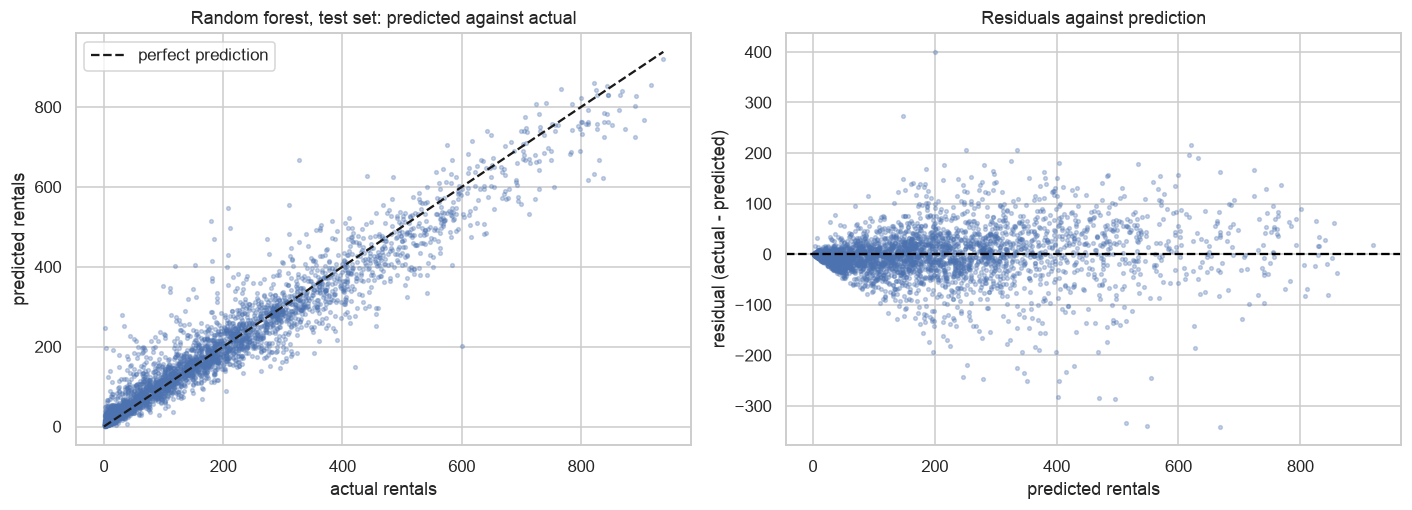

predictions below zero: 0 | minimum prediction 1.92 | maximum prediction 919.9 vs maximum actual 938
             mean_prediction  residual_sd     mae
lowest 20%           17.5000       9.8000  6.9000
20-40%               75.6000      25.6000 20.2000
40-60%              155.9000      46.0000 32.5000
60-80%              252.4000      58.7000 41.6000
highest 20%         473.5000      77.2000 57.0000

MAE by hour and working day (top 6):
hr  workingday
12  0.0000       74.8000
17  0.0000       64.4000
18  1.0000       64.0000
13  0.0000       62.7000
17  1.0000       60.2000
8   1.0000       59.5000

MAE by weathersit:
              mean  size
weathersit              
1          30.4000  2349
2          30.4000   863
3          46.9000   262
4          27.7000     2

five worst test hours: actual [601 327 208 180 211] predicted [201. 668. 548. 514. 497.]


In [32]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(y_test, y_pred, s=6, alpha=0.3)
limit = max(y_test.max(), y_pred.max())
axes[0].plot([0, limit], [0, limit], "k--", linewidth=1.5, label="perfect prediction")
axes[0].set_xlabel("actual rentals")
axes[0].set_ylabel("predicted rentals")
axes[0].set_title("Random forest, test set: predicted against actual")
axes[0].legend()
axes[1].scatter(y_pred, residuals, s=6, alpha=0.3)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("predicted rentals")
axes[1].set_ylabel("residual (actual - predicted)")
axes[1].set_title("Residuals against prediction")
fig.tight_layout()
plt.show()

print("predictions below zero:", int((y_pred < 0).sum()), "| minimum prediction", round(float(y_pred.min()), 2),
      "| maximum prediction", round(float(y_pred.max()), 1), "vs maximum actual", int(y_test.max()))
deciles = pd.qcut(y_pred, 5, labels=["lowest 20%", "20-40%", "40-60%", "60-80%", "highest 20%"])
print(pd.DataFrame({"prediction": y_pred, "residual": residuals, "abs": np.abs(residuals)})
      .groupby(deciles, observed=True)
      .agg(mean_prediction=("prediction", "mean"), residual_sd=("residual", "std"), mae=("abs", "mean"))
      .round(1).to_string())

test_rows = pd.DataFrame(X_test, columns=features.columns)
test_rows["abs_error"] = np.abs(residuals)
test_rows["hr"] = test_rows[[c for c in features.columns if c.startswith("hr_")]].values.argmax(axis=1)
print("\nMAE by hour and working day (top 6):")
print(test_rows.groupby(["hr", "workingday"])["abs_error"].mean().sort_values(ascending=False).head(6).round(1).to_string())
print("\nMAE by weathersit:")
weather_cols = [c for c in features.columns if c.startswith("weathersit_")]
test_rows["weathersit"] = [weather_cols[i].split("_")[1] for i in test_rows[weather_cols].values.argmax(axis=1)]
print(test_rows.groupby("weathersit")["abs_error"].agg(["mean", "size"]).round(1).to_string())
worst = np.argsort(-np.abs(residuals))[:5]
print("\nfive worst test hours: actual", y_test[worst].astype(int), "predicted", y_pred[worst].round(0))

**Your write-up:**

**1. Feature preparation.** `casual` and `registered` are excluded because `casual + registered = cnt` exactly: they are the target split into two parts, and they are not known at the time of the prediction, so using them would be target leakage. I also removed `instant` (a row number), the raw `dteday` string (its useful information is already in `yr`, `mnth` and `weekday`), and `atemp`, which is almost a copy of `temp` (correlation 0.99 in Lesson 2) and has a day with a stuck value (2012-08-17). The encoding:
- `hr`: one-hot, 24 columns. It is the strongest predictor, and its effect on demand is not monotonic (two commuter peaks), so one integer column could not express it.
- `season`, `mnth`, `weekday`: one-hot. They are nominal or cyclic codes, and their effect is not linear in the code (December is next to January, not 11 units away).
- `weathersit`: one-hot. It is ordered by severity, but the steps between the levels are not equal, and one-hot lets the model learn each level's effect.
- `yr`, `holiday`, `workingday`: kept as 0/1. They are binary, so one column loses nothing.
- `temp`, `hum`, `windspeed`: kept numeric. These are real measurements; the scaler inside each pipeline takes care of their scale.

This gives 57 features for 17 379 hours.

**2. Split once.** `test_size=0.2` with `random_state=SEED`: 13 903 rows for development and 3 476 for the test set. With 17 000 rows, 20 % is enough for a precise test estimate (an RMSE based on almost 3 500 hours), and 80 % leaves plenty for 5-fold cross-validation. After the split, the test set was not used until step 6.

**3. Baseline.** Always predicting the training mean gives a CV RMSE of 180.77 ± 1.52 and R² of −0.0006 ± 0.0005, i.e. zero by construction. Every model has to be read against these 181 bicycles.

**4. Models** (5-fold CV on the development set, mean ± SD across folds; every model is a `Pipeline` with a `StandardScaler`):

| model | CV RMSE | CV R² |
|---|---|---|
| baseline (mean) | 180.77 ± 1.52 | −0.001 ± 0.001 |
| linear regression | 101.91 ± 1.94 | 0.682 ± 0.013 |
| k-NN, k = 10 | 79.12 ± 1.16 | 0.808 ± 0.005 |
| decision tree, min leaf 5 | 69.47 ± 2.56 | 0.852 ± 0.011 |
| random forest, 100 trees | 51.69 ± 1.17 | 0.918 ± 0.005 |

The linear model is limited because it cannot combine features: the effect of the hour is different on working days and on weekends, and a linear model can only add the two effects. The non-linear models can learn this interaction, and the random forest is clearly the best, about 18 bicycles better than the single tree, which is far more than the fold-to-fold SD of about 1–2.5.

**5. Tuning.** I tuned the random forest with `GridSearchCV` over `min_samples_leaf` ∈ {1, 3, 5} and `max_features` ∈ {0.5, 1.0}: 6 combinations × 5 folds = 30 fits, plus 1 refit on the whole development set. The best combination was `max_features=0.5`, `min_samples_leaf=1`, with CV RMSE 51.42 ± 1.25 and CV R² 0.9190 ± 0.0048. The improvement over the default forest (51.69) is only 0.27, much smaller than the fold SD, so tuning did not change much. Larger leaves made it clearly worse (58.69 to 59.69 with `min_samples_leaf=5`), so the forest benefits from deep trees.

**6. The test set, opened once.** Test RMSE 49.75, MAE 31.63, R² 0.9267. The CV estimate was RMSE 51.42 and R² 0.919, so the test result is 1.7 bicycles better. This difference is small (between one and two fold SDs) and in the direction of luck rather than of a problem. The test set was not used to choose anything, so this is the number I report, and I did not go back to change the model after seeing it. One caveat: the split is random over hours, so the test hours have neighbours from the same days in the training data (e.g. 16:00 and 18:00 of the same day). For a model that has to predict future days, this makes the estimate somewhat optimistic, and a split by time (train on earlier dates, test on later ones) would be the more honest check.

**7. Diagnosis.** In the predicted-against-actual plot the points lie close to the diagonal, a bit below it for the largest values (the highest prediction is 919.9, the highest actual 938). The model predicts no impossible values: 0 predictions below zero and a minimum of 1.92, because a random forest averages training targets and can never go outside their range. (The linear model in Practice 3 §4 did predict negative rentals.) The residuals clearly fan out. Their SD grows from 9.8 for the lowest 20 % of predictions (mean prediction 17.5) to 25.6, 46.0, 58.7 and 77.2 for the highest 20 % (mean 473.5), and the MAE goes from 6.9 to 57.0. So the error is roughly proportional to the level of demand: quiet night hours are predicted within a few bicycles, busy hours are off by 50–80. The largest mean errors are at midday on non-working days (12:00: MAE 74.8, 13:00: 62.7, 17:00: 64.4) and at the working-day peaks (18:00: 64.0, 17:00: 60.2, 8:00: 59.5), and in light rain or snow (MAE 46.9 against 30.4 in clear weather). These are the hours where demand depends most on things the features do not describe well, such as weather within the hour or special events. The worst single hours show this: one hour with 601 actual rentals predicted as 201, and several hours with 180 to 330 actual rentals predicted at 500 to 670.

**8. Decision.** I would deploy the tuned random forest (`max_features=0.5`, `min_samples_leaf=1`, 100 trees). On new hours from the same period I would expect a typical error of about 50 bicycles per hour in RMSE terms (49.75 on the test set, 51.4 in cross-validation), or about 32 bicycles in terms of the average absolute error. But I would say clearly that the error depends on the hour: at night it is within about 7 bicycles, at busy hours it is 50–80, i.e. roughly 15–20 % of the demand. I would also say that this was measured on hours mixed randomly across 2011–2012, so it should be re-checked on a later period before being trusted for forecasting. The single change I would test first is modelling log(1 + cnt) instead of `cnt`. The fan-shaped residuals show that the errors grow with the level of demand, which suggests multiplicative effects (weather and hour scaling demand up or down), and a log target would make the errors more even across quiet and busy hours.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.